In [106]:
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf 
import pandas as pd 
from tensorflow.keras.models import Sequential # Sequntial API
from tensorflow.keras.models import Model # Functional API & SubclassAPI
from tensorflow.keras.layers import * # layers to put

from tensorflow.keras.optimizers import SGD # (SGD, Momentum, NAG) not adaptive optimizers (tune lr)
from tensorflow.keras.optimizers import RMSprop, Adam, Adamax, Nadam, AdamW, Adagrad 

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard

import matplotlib.pyplot as plt

import numpy as np



In [107]:
with open("train.txt", mode='r', encoding='utf-8') as df:
    lines = df.readlines()
print(''.join(lines[:20]))

-DOCSTART- -X- -X- O

EU NNP B-NP B-ORG
rejects VBZ B-VP O
German JJ B-NP B-MISC
call NN I-NP O
to TO B-VP O
boycott VB I-VP O
British JJ B-NP B-MISC
lamb NN I-NP O
. . O O

Peter NNP B-NP B-PER
Blackburn NNP I-NP I-PER

BRUSSELS NNP B-NP B-LOC
1996-08-22 CD I-NP O

The DT B-NP O
European NNP I-NP B-ORG



In [108]:
def load_sentences(filepath):
    final = []
    sentences = []
    with open(filepath, 'r') as f:
        for line in f.readlines():
            if (line == ('-DOCSTART- -X- -X- O\n') or line == '\n'):
                if len(sentences) > 0:
                    final.append(sentences)
                    sentences = []
            else:
                l = line.split(' ')
                sentences.append((l[0], l[3].strip('\n')))
    return final
train_sents = load_sentences('train.txt')
test_sents = load_sentences('test.txt')
val_sents = load_sentences('valid.txt')
train_sents

[[('EU', 'B-ORG'),
  ('rejects', 'O'),
  ('German', 'B-MISC'),
  ('call', 'O'),
  ('to', 'O'),
  ('boycott', 'O'),
  ('British', 'B-MISC'),
  ('lamb', 'O'),
  ('.', 'O')],
 [('Peter', 'B-PER'), ('Blackburn', 'I-PER')],
 [('BRUSSELS', 'B-LOC'), ('1996-08-22', 'O')],
 [('The', 'O'),
  ('European', 'B-ORG'),
  ('Commission', 'I-ORG'),
  ('said', 'O'),
  ('on', 'O'),
  ('Thursday', 'O'),
  ('it', 'O'),
  ('disagreed', 'O'),
  ('with', 'O'),
  ('German', 'B-MISC'),
  ('advice', 'O'),
  ('to', 'O'),
  ('consumers', 'O'),
  ('to', 'O'),
  ('shun', 'O'),
  ('British', 'B-MISC'),
  ('lamb', 'O'),
  ('until', 'O'),
  ('scientists', 'O'),
  ('determine', 'O'),
  ('whether', 'O'),
  ('mad', 'O'),
  ('cow', 'O'),
  ('disease', 'O'),
  ('can', 'O'),
  ('be', 'O'),
  ('transmitted', 'O'),
  ('to', 'O'),
  ('sheep', 'O'),
  ('.', 'O')],
 [('Germany', 'B-LOC'),
  ("'s", 'O'),
  ('representative', 'O'),
  ('to', 'O'),
  ('the', 'O'),
  ('European', 'B-ORG'),
  ('Union', 'I-ORG'),
  ("'s", 'O'),
  ('vete

In [109]:
sentences = [[word for word, label in s] for s in train_sents]
tags = [[label for word, label in s] for s in train_sents]
sentences

[['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'],
 ['Peter', 'Blackburn'],
 ['BRUSSELS', '1996-08-22'],
 ['The',
  'European',
  'Commission',
  'said',
  'on',
  'Thursday',
  'it',
  'disagreed',
  'with',
  'German',
  'advice',
  'to',
  'consumers',
  'to',
  'shun',
  'British',
  'lamb',
  'until',
  'scientists',
  'determine',
  'whether',
  'mad',
  'cow',
  'disease',
  'can',
  'be',
  'transmitted',
  'to',
  'sheep',
  '.'],
 ['Germany',
  "'s",
  'representative',
  'to',
  'the',
  'European',
  'Union',
  "'s",
  'veterinary',
  'committee',
  'Werner',
  'Zwingmann',
  'said',
  'on',
  'Wednesday',
  'consumers',
  'should',
  'buy',
  'sheepmeat',
  'from',
  'countries',
  'other',
  'than',
  'Britain',
  'until',
  'the',
  'scientific',
  'advice',
  'was',
  'clearer',
  '.'],
 ['"',
  'We',
  'do',
  "n't",
  'support',
  'any',
  'such',
  'recommendation',
  'because',
  'we',
  'do',
  "n't",
  'see',
  'any',
  'grounds',
  'fo

In [110]:
def get_df(samples):
    df, label = [], []
    for lines in samples:
        cur_line, cur_label = list(zip(*lines))
        df.append(list(cur_line))
        label.append(list(cur_label))   
    return {'text': df, 'label': label}

train_data = get_df(train_sents)
val_data = get_df(val_sents)
test_data = get_df(test_sents)
train_data

{'text': [['EU',
   'rejects',
   'German',
   'call',
   'to',
   'boycott',
   'British',
   'lamb',
   '.'],
  ['Peter', 'Blackburn'],
  ['BRUSSELS', '1996-08-22'],
  ['The',
   'European',
   'Commission',
   'said',
   'on',
   'Thursday',
   'it',
   'disagreed',
   'with',
   'German',
   'advice',
   'to',
   'consumers',
   'to',
   'shun',
   'British',
   'lamb',
   'until',
   'scientists',
   'determine',
   'whether',
   'mad',
   'cow',
   'disease',
   'can',
   'be',
   'transmitted',
   'to',
   'sheep',
   '.'],
  ['Germany',
   "'s",
   'representative',
   'to',
   'the',
   'European',
   'Union',
   "'s",
   'veterinary',
   'committee',
   'Werner',
   'Zwingmann',
   'said',
   'on',
   'Wednesday',
   'consumers',
   'should',
   'buy',
   'sheepmeat',
   'from',
   'countries',
   'other',
   'than',
   'Britain',
   'until',
   'the',
   'scientific',
   'advice',
   'was',
   'clearer',
   '.'],
  ['"',
   'We',
   'do',
   "n't",
   'support',
   'any',
  

In [111]:
def get_to_pd_df(data):
    data_pd=pd.DataFrame({
    'sentence': [' '.join(words) for words in data['text']],
    'words': data['text'],
    'labels': data['label']
    })
    return data_pd 
train_df = get_to_pd_df(train_data)
val_df   = get_to_pd_df(val_data)
test_df  = get_to_pd_df(test_data)
train_df

,sentence,words,labels
0,EU rejects German call to boycott British lamb .,"[EU, rejects, German, call, to, boycott, Briti...","[B-ORG, O, B-MISC, O, O, O, B-MISC, O, O]"
1,Peter Blackburn,"[Peter, Blackburn]","[B-PER, I-PER]"
2,BRUSSELS 1996-08-22,"[BRUSSELS, 1996-08-22]","[B-LOC, O]"
3,The European Commission said on Thursday it di...,"[The, European, Commission, said, on, Thursday...","[O, B-ORG, I-ORG, O, O, O, O, O, O, B-MISC, O,..."
4,Germany 's representative to the European Unio...,"[Germany, 's, representative, to, the, Europea...","[B-LOC, O, O, O, O, B-ORG, I-ORG, O, O, O, B-P..."
...,...,...,...
14036,on Friday :,"[on, Friday, :]","[O, O, O]"
14037,Division two,"[Division, two]","[O, O]"
14038,Plymouth 2 Preston 1,"[Plymouth, 2, Preston, 1]","[B-ORG, O, B-ORG, O]"
14039,Division three,"[Division, three]","[O, O]"


In [112]:
max_word = train_df['words'].explode().nunique()
num_tag = train_df['labels'].explode().nunique()
print(f'Number of unique words in the dataset {max_word}')
print(f' Number of unique tags in the dataset {num_tag}')
max_word = train_df['words'].explode().nunique() +700
num_tag = train_df['labels'].explode().nunique()

Number of unique words in the dataset 23623
 Number of unique tags in the dataset 9


In [113]:
train_df['labels'].explode().value_counts()

O         169578
B-LOC       7140
B-PER       6600
B-ORG       6321
I-PER       4528
I-ORG       3704
B-MISC      3438
I-LOC       1157
I-MISC      1155
Name: labels, dtype: int64

In [114]:
X_train =list(train_df['sentence']) 
y_train = list(train_df['labels'])

X_val = list(val_df['sentence'])
y_val = list(val_df['labels'])

X_test = list(val_df['sentence'])
y_test = list(val_df['labels'])

X_train[:3]

['EU rejects German call to boycott British lamb .',
 'Peter Blackburn',
 'BRUSSELS 1996-08-22']

In [115]:
y_train

[['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O'],
 ['B-PER', 'I-PER'],
 ['B-LOC', 'O'],
 ['O',
  'B-ORG',
  'I-ORG',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-MISC',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-MISC',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O'],
 ['B-LOC',
  'O',
  'O',
  'O',
  'O',
  'B-ORG',
  'I-ORG',
  'O',
  'O',
  'O',
  'B-PER',
  'I-PER',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-LOC',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O'],
 ['O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-ORG',
  'O',
  'O',
  'O',
  'B-PER',
  'I-PER',
  'I-PER',
  'I-PER',
  'O',
  'O',
  'O',
  'O',
  'O'],
 ['O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-ORG',
  'I-ORG',
 

In [116]:
text_vec_layer = TextVectorization(max_tokens=max_word, standardize='lower_and_strip_punctuation',output_sequence_length=100)
text_vec_layer.adapt(X_train)

X_train_encod=text_vec_layer(X_train)
X_val_encod=text_vec_layer(X_val)
X_test_encod=text_vec_layer(X_test)

X_test_encod


<tf.Tensor: shape=(3250, 100), dtype=int64, numpy=
array([[  298,  2472,   256, ...,     0,     0,     0],
       [   92,  2599,     0, ...,     0,     0,     0],
       [  241,   919,  7232, ...,     0,     0,     0],
       ...,
       [   44,     9,    95, ...,     0,     0,     0],
       [    2, 16250,   115, ...,     0,     0,     0],
       [ 1402,   138,     1, ...,     0,     0,     0]], dtype=int64)>

In [117]:
print(text_vec_layer.get_vocabulary())
n_tokkens = text_vec_layer.vocabulary_size()
n_tokkens

['', '[UNK]', 'the', 'of', 'in', 'to', 'a', 'and', 'on', 'said', 's', '1', 'for', 'at', 'was', '2', '3', '0', 'with', 'that', 'he', 'from', 'it', 'by', 'is', '4', 'as', 'had', 'his', 'has', 'but', 'an', 'not', 'were', 'be', 'after', 'have', 'first', 'new', '5', 'who', 'us', '6', 'will', 'they', 'two', 'been', 'their', 'beat', 'are', 'would', 'which', 'this', 'up', '7', 'its', 'i', 'year', 'last', 'percent', 'out', 'we', 'thursday', 'one', '10', 'over', 'million', 'government', 'wednesday', 'police', 'results', 'against', 'when', 'second', 'also', 'tuesday', 'three', 'soccer', '8', '12', 'president', '9', 'no', 'division', 'told', 'monday', 'people', 'about', 'or', 'league', 'friday', 'some', 'london', '64', 'world', 'there', 'her', 'minister', 'under', 'more', 'york', '19960828', 'won', 'state', 'into', 'sunday', '63', '11', 'south', 'before', 'played', 'market', 'group', 'week', 'england', 'all', 'time', '21', 'than', 'germany', 'could', 'other', 'australia', 'she', '62', 'since', 'po

20070

In [118]:
input_ids = text_vec_layer('new text')
input_ids

<tf.Tensor: shape=(100,), dtype=int64, numpy=
array([  38, 5906,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0], dtype=int64)>

In [119]:
def decode_tokens_into_text(input_ids, text_vec_layer):
    text = ""
    for token in input_ids:
        text = text + text_vec_layer.get_vocabulary()[token]+" "
    return text.strip()
decode_tokens_into_text(input_ids, text_vec_layer)

'new text'

In [120]:
tags = train_df['labels'].explode().unique()
tags

array(['B-ORG', 'O', 'B-MISC', 'B-PER', 'I-PER', 'B-LOC', 'I-ORG',
       'I-MISC', 'I-LOC'], dtype=object)

In [121]:
tags2id = {}
for i, tag in enumerate(tags):
    tags2id[tag] = i
tags2id

{'B-ORG': 0,
 'O': 1,
 'B-MISC': 2,
 'B-PER': 3,
 'I-PER': 4,
 'B-LOC': 5,
 'I-ORG': 6,
 'I-MISC': 7,
 'I-LOC': 8}

In [122]:
id2tag = {}
for key, value in tags2id.items():
    id2tag[value] = key
id2tag

{0: 'B-ORG',
 1: 'O',
 2: 'B-MISC',
 3: 'B-PER',
 4: 'I-PER',
 5: 'B-LOC',
 6: 'I-ORG',
 7: 'I-MISC',
 8: 'I-LOC'}

In [123]:
def encode_Y_data(Y_data):
    Y_ids = [[tags2id[tag] for tag in seq] for seq in Y_data]
    Y_preprocessed = pad_sequences(Y_ids, maxlen=100, padding='post', value=tags2id['O'])
    return Y_preprocessed

y_train_preprocessed = encode_Y_data(y_train)
y_val_preprocessed = encode_Y_data(y_val)
y_test_preprocessed = encode_Y_data(y_test)
y_train_preprocessed

array([[0, 1, 2, ..., 1, 1, 1],
       [3, 4, 1, ..., 1, 1, 1],
       [5, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 1, 0, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 1, 0, ..., 1, 1, 1]])

In [124]:
def to_dataset(X_data,Y_data, shuffle=False, batch_size=32):
    x_y_tf_dataset = tf.data.Dataset.from_tensor_slices((X_data, Y_data))

    # Gradient Descent: IID
    if shuffle:
        x_y_tf_dataset = x_y_tf_dataset.shuffle(buffer_size=1000, seed=42)
    x_y_tf_dataset = x_y_tf_dataset.batch(batch_size=batch_size).prefetch(1)
    return x_y_tf_dataset

In [125]:
X_train_encod.shape,y_train_preprocessed.shape

(TensorShape([14041, 100]), (14041, 100))

In [126]:
X_y_tarin_dataset = to_dataset(X_train_encod,y_train_preprocessed)
X_y_val_dataset   = to_dataset(X_train_encod,y_train_preprocessed)
X_y_test_dataset  = to_dataset(X_train_encod,y_train_preprocessed)

In [127]:
input_ = Input(shape=(X_train_encod.shape[1],))
hidden = Embedding(n_tokkens, 16)(input_)
hidden = SimpleRNN(128, activation='tanh', kernel_initializer='glorot_uniform',return_sequences=True)(hidden) 
outpu=TimeDistributed(Dense(num_tag, activation='softmax'))(hidden)
model = Model(inputs=[input_], outputs=[outpu])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 100, 16)        │       321,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 100, 128)       │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 100, 9)         │         1,161 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 340,841 (1.30 MB)

 Trainable params: 340,841 (1.30 MB)

 Non-trainable params: 0 (0.00 B)

In [128]:
optimizer = Nadam(learning_rate=1e-3)

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

model_ckpt = ModelCheckpoint("my_model.keras", monitor="val_accuracy", save_best_only=True)
history = model.fit(X_y_tarin_dataset, validation_data=X_y_val_dataset, epochs=10, callbacks=[model_ckpt])

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 34s 58ms/step - accuracy: 0.9717 - loss: 0.1425 - val_accuracy: 0.9758 - val_loss: 0.1009
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.9764 - loss: 0.0915 - val_accuracy: 0.9774 - val_loss: 0.0915
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.9793 - loss: 0.0784 - val_accuracy: 0.9818 - val_loss: 0.0682
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.9831 - loss: 0.0620 - val_accuracy: 0.9861 - val_loss: 0.0514
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.9867 - loss: 0.0476 - val_accuracy: 0.9895 - val_loss: 0.0376
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.9892 - loss: 0.0403 - val_accuracy: 0.9911 - val_loss: 0.0331
Epoch 7/10
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9907 - loss: 0.0335

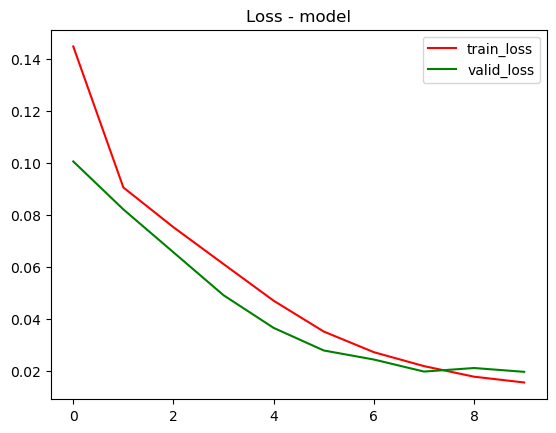

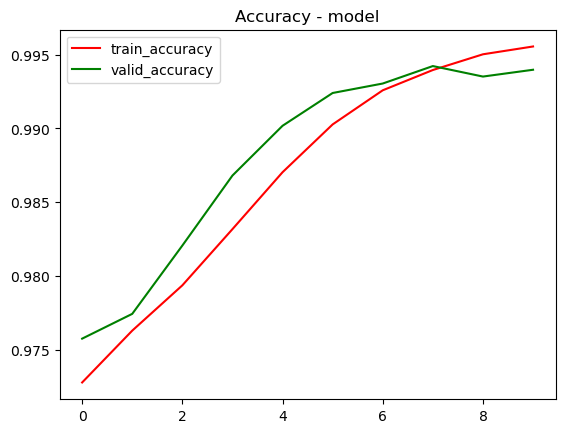

In [ ]:
def plot_loss_acc(history, model_name='model_1'):
    plt.title(f"Loss - {model_name}")
    plt.plot(history.history['loss'], c='red', label='train_loss')
    plt.plot(history.history['val_loss'], c='green', label='valid_loss')
    plt.legend()
    plt.show()

    plt.title(f"Accuracy - {model_name}")
    plt.plot(history.history['accuracy'], c='red', label='train_accuracy')
    plt.plot(history.history['val_accuracy'], c='green', label='valid_accuracy')
    plt.legend()
    plt.show()

plot_loss_acc(history, model_name='model')

In [ ]:
new_text = ["my name is mohamed magdan i  live in Cairo"]
new_text_enc = text_vec_layer(new_text)
pred = model.predict(new_text_enc)


pred_ids = np.argmax(pred, axis=-1)[0] 

decoded_tags = [id2tag[i] for i in pred_ids]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [ ]:
tokens = text_vec_layer.get_vocabulary()

words = new_text[0].split()

for w, t in zip(words, decoded_tags[:len(words)]):
    print(f"{w:15} → {t}")

my              → O
name            → O
is              → O
mohamed         → B-PER
magdan          → I-PER
i               → I-PER
live            → O
in              → O
Cairo           → O


In [ ]:
model.evaluate(X_y_test_dataset)

439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9940 - loss: 0.0197


[0.019689597189426422, 0.9939782023429871]

In [ ]:
tokens = text_vec_layer.get_vocabulary()

words = test_df['sentence'][0].split()

for w, t in zip(words, decoded_tags[:len(words)]):
    print(f"{w:15} → {t}")

SOCCER          → O
-               → O
JAPAN           → O
GET             → B-PER
LUCKY           → I-PER
WIN             → I-PER
,               → O
CHINA           → O
IN              → O
SURPRISE        → O
DEFEAT          → O
.               → O


In [ ]:
model.save("my_model.h5")